In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load your proper dataset
df = pd.read_csv("../dataset/prompt_injection_dataset.csv")
print("Shape:", df.shape)
print(df['label'].value_counts())

Shape: (4391, 8)
label
1    2650
0    1741
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Split data
X = df['text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert text to numbers
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# Evaluate
y_pred = model.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nDetailed report:")
print(classification_report(y_test, y_pred, target_names=['benign', 'injection']))

Accuracy: 0.9488054607508533

Detailed report:
              precision    recall  f1-score   support

      benign       0.99      0.88      0.93       346
   injection       0.93      0.99      0.96       533

    accuracy                           0.95       879
   macro avg       0.96      0.94      0.95       879
weighted avg       0.95      0.95      0.95       879



In [3]:
import joblib

joblib.dump(model, '../backend/model.pkl')
joblib.dump(vectorizer, '../backend/vectorizer.pkl')
print("Model saved!")

Model saved!


Matplotlib is building the font cache; this may take a moment.


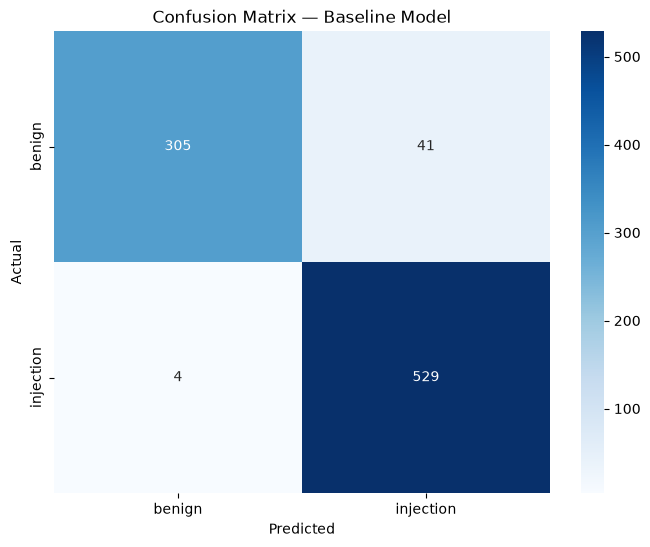

Saved!


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['benign', 'injection'],
            yticklabels=['benign', 'injection'])
plt.title('Confusion Matrix — Baseline Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('../dataset/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [5]:
import sys
!{sys.executable} -m pip install matplotlib seaborn

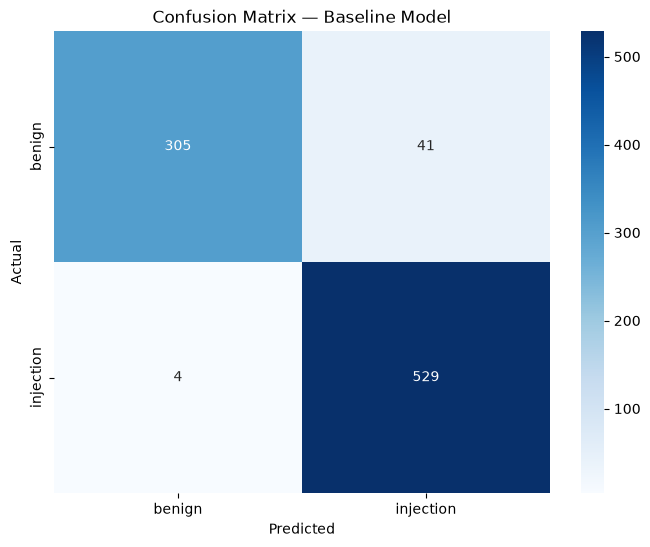

Saved!


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['benign', 'injection'],
            yticklabels=['benign', 'injection'])
plt.title('Confusion Matrix — Baseline Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('../dataset/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

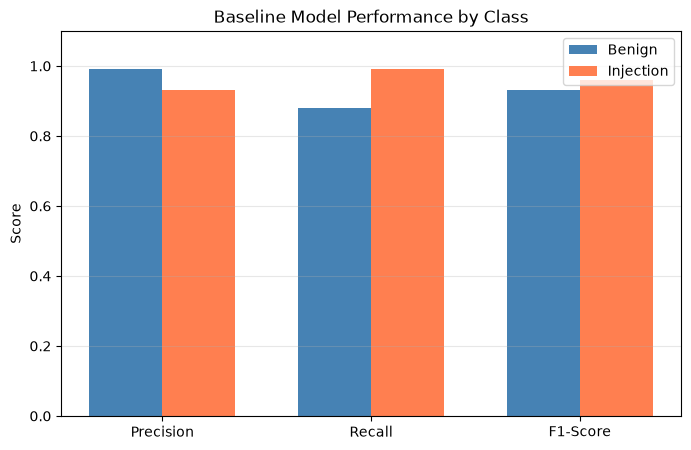

Saved!


In [7]:
# Performance bar chart
metrics = ['Precision', 'Recall', 'F1-Score']
benign = [0.99, 0.88, 0.93]
injection = [0.93, 0.99, 0.96]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, benign, width, label='Benign', color='steelblue')
ax.bar(x + width/2, injection, width, label='Injection', color='coral')

ax.set_ylabel('Score')
ax.set_title('Baseline Model Performance by Class')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.savefig('../dataset/performance_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [8]:
import sys
!{sys.executable} -m pip install transformers torch scikit-learn

In [9]:
from sklearn.utils import resample

# Separate classes
benign = df[df['label'] == 0]
injection = df[df['label'] == 1]

print(f"Before balancing - Benign: {len(benign)}, Injection: {len(injection)}")

# Upsample benign to match injection count
benign_upsampled = resample(benign, replace=True, n_samples=len(injection), random_state=42)
df_balanced = pd.concat([benign_upsampled, injection]).sample(frac=1, random_state=42)

print(f"After balancing - Benign: {len(df_balanced[df_balanced['label']==0])}, Injection: {len(df_balanced[df_balanced['label']==1])}")

# Save balanced dataset
df_balanced.to_csv('../dataset/balanced_dataset.csv', index=False)
print("Saved!")

Before balancing - Benign: 1741, Injection: 2650
After balancing - Benign: 2650, Injection: 2650
Saved!


In [10]:
# Retrain baseline on balanced dataset
df_balanced = pd.read_csv("../dataset/balanced_dataset.csv")
print(df_balanced['label'].value_counts())

X = df_balanced['text']
y = df_balanced['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer_v2 = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer_v2.fit_transform(X_train)
X_test_tfidf = vectorizer_v2.transform(X_test)

model_v2 = LogisticRegression(max_iter=1000)
model_v2.fit(X_train_tfidf, y_train)

y_pred = model_v2.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['benign', 'injection']))

label
1    2650
0    2650
Name: count, dtype: int64
Accuracy: 0.9556603773584905
              precision    recall  f1-score   support

      benign       0.97      0.94      0.95       528
   injection       0.94      0.97      0.96       532

    accuracy                           0.96      1060
   macro avg       0.96      0.96      0.96      1060
weighted avg       0.96      0.96      0.96      1060

